# Music-CRS input data EDA

`input/` 配下の HuggingFace snapshot を対象に、会話データ、track/user metadata、track/user embeddings の整合性・分布・leakage リスク・baseline 改善の観点を確認します。

この Notebook は上から順に再実行できる構成です。集計表は `EDA/tables/`、図は `EDA/figures/`、要約は `EDA/summary/input-data-eda-summary.md` に保存します。

## Setup

Notebook 実行に必要な package を import し、入力・出力パスを固定します。Embedding parquet は大きいため、norm と ID coverage は batch 単位で読みます。

In [1]:
from __future__ import annotations

from collections import Counter, defaultdict
from pathlib import Path
import math
import os
import re

from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

def find_repo_root(start: Path) -> Path:
    """Find the repository root from a notebook working directory."""
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "AGENTS.md").exists() and (path / "input").exists():
            return path
    raise FileNotFoundError(f"Could not find repository root from {start}")


ROOT = find_repo_root(Path.cwd())
INPUT = ROOT / "input"
EDA_DIR = ROOT / "EDA"
TABLE_DIR = EDA_DIR / "tables"
FIGURE_DIR = EDA_DIR / "figures"
SUMMARY_PATH = EDA_DIR / "summary" / "input-data-eda-summary.md"

for path in [EDA_DIR, TABLE_DIR, FIGURE_DIR, SUMMARY_PATH.parent]:
    path.mkdir(parents=True, exist_ok=True)

EXPECTED_COUNTS = {
    "conversation_train": 15199,
    "conversation_dev_test": 1000,
    "conversation_blind_a": 80,
    "track_metadata_all_tracks": 47071,
    "user_metadata_all_users": 8772,
}

print(f"input root: {INPUT}")
print(f"tables: {TABLE_DIR}")
print(f"figures: {FIGURE_DIR}")

/home/tomoya/kaggle/music-crs-baselines/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


input root: /home/tomoya/kaggle/music-crs-baselines/input
tables: /home/tomoya/kaggle/music-crs-baselines/EDA/tables
figures: /home/tomoya/kaggle/music-crs-baselines/EDA/figures


## Data inventory

parquet ファイルの一覧、行数、列、型、ファイルサイズを確認します。README 由来の期待 row count と後続セルで照合します。

In [2]:
def infer_split_name(path: Path) -> str:
    stem = path.stem
    return re.sub(r"-\d{5}-of-\d{5}$", "", stem)

inventory_rows = []
for parquet_path in sorted(INPUT.glob("*/data/*.parquet")):
    pf = pq.ParquetFile(parquet_path)
    schema_fields = {field.name: str(field.type) for field in pf.schema_arrow}
    dataset_name = parquet_path.parents[1].name
    split_name = infer_split_name(parquet_path)
    inventory_rows.append({
        "dataset": dataset_name,
        "split": split_name,
        "file": str(parquet_path.relative_to(ROOT)),
        "size_mb": parquet_path.stat().st_size / 1024 / 1024,
        "rows": pf.metadata.num_rows,
        "row_groups": pf.metadata.num_row_groups,
        "num_columns": len(schema_fields),
        "columns": ", ".join(schema_fields.keys()),
        "schema": schema_fields,
    })

data_inventory = pd.DataFrame(inventory_rows)
data_inventory.to_csv(TABLE_DIR / "data_inventory.csv", index=False)
display(data_inventory[["dataset", "split", "rows", "size_mb", "num_columns", "columns"]])

,dataset,split,rows,size_mb,num_columns,columns
0,TalkPlayData-Challenge-Blind-A,test,80,0.435561,7,"session_id, user_id, session_date, user_profile, conversation_goal, conversations, goal_progress_assessments"
1,TalkPlayData-Challenge-Dataset,test,1000,6.250875,7,"session_id, user_id, session_date, user_profile, conversation_goal, conversations, goal_progress_assessments"
2,TalkPlayData-Challenge-Dataset,train,15199,84.438450,7,"session_id, user_id, session_date, user_profile, conversation_goal, conversations, goal_progress_assessments"
3,TalkPlayData-Challenge-Track-Embeddings,all_tracks,11768,164.365793,7,"track_id, audio-laion_clap, image-siglip2, cf-bpr, attributes-qwen3_embedding_0.6b, lyrics-qwen3_embedding_0.6b, met..."
4,TalkPlayData-Challenge-Track-Embeddings,all_tracks,11768,164.244337,7,"track_id, audio-laion_clap, image-siglip2, cf-bpr, attributes-qwen3_embedding_0.6b, lyrics-qwen3_embedding_0.6b, met..."
5,TalkPlayData-Challenge-Track-Embeddings,all_tracks,11768,164.495667,7,"track_id, audio-laion_clap, image-siglip2, cf-bpr, attributes-qwen3_embedding_0.6b, lyrics-qwen3_embedding_0.6b, met..."
6,TalkPlayData-Challenge-Track-Embeddings,all_tracks,11767,164.677839,7,"track_id, audio-laion_clap, image-siglip2, cf-bpr, attributes-qwen3_embedding_0.6b, lyrics-qwen3_embedding_0.6b, met..."
7,TalkPlayData-Challenge-Track-Embeddings,test_tracks,7405,97.479793,7,"track_id, audio-laion_clap, image-siglip2, cf-bpr, attributes-qwen3_embedding_0.6b, lyrics-qwen3_embedding_0.6b, met..."
8,TalkPlayData-Challenge-Track-Metadata,all_tracks,47071,17.377553,11,"track_id, ISRC, track_name, artist_name, album_name, tag_list, popularity, release_date, duration, artist_id, album_id"
9,TalkPlayData-Challenge-Track-Metadata,test_tracks,7405,2.109971,11,"track_id, ISRC, track_name, artist_name, album_name, tag_list, popularity, release_date, duration, artist_id, album_id"


## Load datasets

会話、metadata は `datasets.load_dataset` で local snapshot から読みます。Track embeddings は大きいため、この段階では parquet path のみ保持します。

In [3]:
conversation_train = load_dataset(str(INPUT / "TalkPlayData-Challenge-Dataset"), split="train")
conversation_dev = load_dataset(str(INPUT / "TalkPlayData-Challenge-Dataset"), split="test")
conversation_blind_a = load_dataset(str(INPUT / "TalkPlayData-Challenge-Blind-A"), split="test")
track_all = load_dataset(str(INPUT / "TalkPlayData-Challenge-Track-Metadata"), split="all_tracks")
track_test = load_dataset(str(INPUT / "TalkPlayData-Challenge-Track-Metadata"), split="test_tracks")
user_all = load_dataset(str(INPUT / "TalkPlayData-Challenge-User-Metadata"), split="all_users")

track_embedding_paths_all = sorted((INPUT / "TalkPlayData-Challenge-Track-Embeddings" / "data").glob("all_tracks-*.parquet"))
track_embedding_paths_test = sorted((INPUT / "TalkPlayData-Challenge-Track-Embeddings" / "data").glob("test_tracks-*.parquet"))
user_embedding_paths = sorted((INPUT / "TalkPlayData-Challenge-User-Embeddings" / "data").glob("*.parquet"))

row_counts = pd.DataFrame([
    {"name": "conversation_train", "rows": len(conversation_train), "expected": EXPECTED_COUNTS["conversation_train"]},
    {"name": "conversation_dev_test", "rows": len(conversation_dev), "expected": EXPECTED_COUNTS["conversation_dev_test"]},
    {"name": "conversation_blind_a", "rows": len(conversation_blind_a), "expected": EXPECTED_COUNTS["conversation_blind_a"]},
    {"name": "track_metadata_all_tracks", "rows": len(track_all), "expected": EXPECTED_COUNTS["track_metadata_all_tracks"]},
    {"name": "track_metadata_test_tracks", "rows": len(track_test), "expected": 7405},
    {"name": "user_metadata_all_users", "rows": len(user_all), "expected": EXPECTED_COUNTS["user_metadata_all_users"]},
])
row_counts["matches_expected"] = row_counts["rows"] == row_counts["expected"]
display(row_counts)
assert row_counts["matches_expected"].all(), row_counts

,name,rows,expected,matches_expected
0,conversation_train,15199,15199,True
1,conversation_dev_test,1000,1000,True
2,conversation_blind_a,80,80,True
3,track_metadata_all_tracks,47071,47071,True
4,track_metadata_test_tracks,7405,7405,True
5,user_metadata_all_users,8772,8772,True


## Conversation EDA

train / dev / Blind A の session、user、role、turn、goal 分布を集計します。Blind A は観測済み conversation 構造だけを扱い、未来 turn や非公開正解を推測しません。

In [4]:
def conversation_tables(ds, split_name: str):
    session_rows = []
    turn_rows = []
    music_rows = []
    for item in ds:
        conversations = item["conversations"]
        user_profile = item["user_profile"] or {}
        goal = item["conversation_goal"] or {}
        roles = Counter(turn["role"] for turn in conversations)
        turn_numbers = [turn["turn_number"] for turn in conversations]
        music_ids = [turn["content"] for turn in conversations if turn["role"] == "music"]
        session_rows.append({
            "split": split_name,
            "session_id": item["session_id"],
            "user_id": item["user_id"],
            "session_date": item["session_date"],
            "user_split": user_profile.get("user_split"),
            "goal_category": goal.get("category"),
            "goal_specificity": goal.get("specificity"),
            "listener_goal": goal.get("listener_goal"),
            "num_conversation_rows": len(conversations),
            "num_unique_turns": len(set(turn_numbers)),
            "num_user_messages": roles.get("user", 0),
            "num_assistant_messages": roles.get("assistant", 0),
            "num_music_messages": roles.get("music", 0),
            "num_music_unique": len(set(music_ids)),
            "has_repeated_music_in_session": len(music_ids) != len(set(music_ids)),
        })
        for turn in conversations:
            turn_rows.append({
                "split": split_name,
                "session_id": item["session_id"],
                "user_id": item["user_id"],
                "goal_category": goal.get("category"),
                "turn_number": turn["turn_number"],
                "role": turn["role"],
                "content": turn["content"],
                "content_chars": len(turn["content"] or ""),
                "has_thought": bool(turn.get("thought")),
            })
            if turn["role"] == "music":
                music_rows.append({
                    "split": split_name,
                    "session_id": item["session_id"],
                    "user_id": item["user_id"],
                    "goal_category": goal.get("category"),
                    "turn_number": turn["turn_number"],
                    "track_id": turn["content"],
                })
    return pd.DataFrame(session_rows), pd.DataFrame(turn_rows), pd.DataFrame(music_rows)

session_frames, turn_frames, music_frames = [], [], []
for split_name, ds in [
    ("train", conversation_train),
    ("dev_test", conversation_dev),
    ("blind_a", conversation_blind_a),
]:
    sessions, turns, music = conversation_tables(ds, split_name)
    session_frames.append(sessions)
    turn_frames.append(turns)
    music_frames.append(music)

sessions_df = pd.concat(session_frames, ignore_index=True)
turns_df = pd.concat(turn_frames, ignore_index=True)
music_df = pd.concat(music_frames, ignore_index=True)

conversation_stats = sessions_df.groupby("split").agg(
    sessions=("session_id", "nunique"),
    users=("user_id", "nunique"),
    avg_rows=("num_conversation_rows", "mean"),
    avg_unique_turns=("num_unique_turns", "mean"),
    avg_music_messages=("num_music_messages", "mean"),
    repeated_music_sessions=("has_repeated_music_in_session", "sum"),
).reset_index()
role_stats = turns_df.groupby(["split", "role"]).size().reset_index(name="rows")
turn_stats = turns_df.groupby(["split", "turn_number", "role"]).size().reset_index(name="rows")
goal_stats = sessions_df.groupby(["split", "goal_category", "goal_specificity"], dropna=False).size().reset_index(name="sessions")

conversation_stats.to_csv(TABLE_DIR / "conversation_stats.csv", index=False)
role_stats.to_csv(TABLE_DIR / "role_stats.csv", index=False)
turn_stats.to_csv(TABLE_DIR / "turn_stats.csv", index=False)
goal_stats.to_csv(TABLE_DIR / "goal_stats.csv", index=False)

display(conversation_stats)
display(role_stats.pivot(index="split", columns="role", values="rows").fillna(0).astype(int))

,split,sessions,users,avg_rows,avg_unique_turns,avg_music_messages,repeated_music_sessions
0,blind_a,80,58,8.875,3.625,2.625,0
1,dev_test,1000,500,24.000,8.000,8.000,0
2,train,15199,8591,24.000,8.000,8.000,0


role,assistant,music,user
split,,,
blind_a,210,210,290
dev_test,8000,8000,8000
train,121592,121592,121592


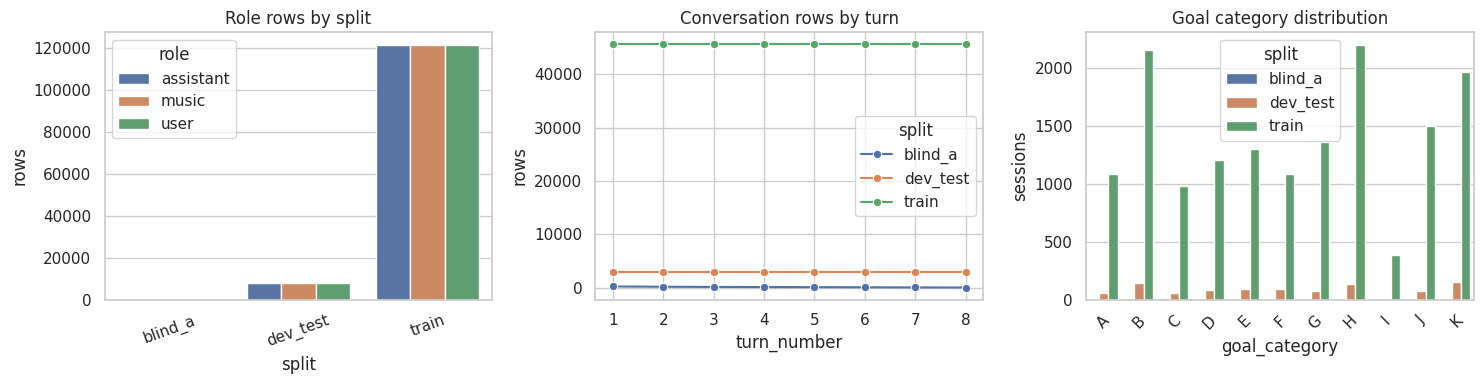

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=role_stats, x="split", y="rows", hue="role", ax=axes[0])
axes[0].set_title("Role rows by split")
axes[0].tick_params(axis="x", rotation=20)

turn_total = turns_df.groupby(["split", "turn_number"]).size().reset_index(name="rows")
sns.lineplot(data=turn_total, x="turn_number", y="rows", hue="split", marker="o", ax=axes[1])
axes[1].set_title("Conversation rows by turn")
axes[1].set_xticks(range(1, 9))

goal_category = sessions_df.groupby(["split", "goal_category"]).size().reset_index(name="sessions")
sns.barplot(data=goal_category, x="goal_category", y="sessions", hue="split", ax=axes[2])
axes[2].set_title("Goal category distribution")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "conversation_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

## Music track frequency in conversations

train/dev/Blind A の会話内 `music` role で参照される track_id の頻度を見ます。Baseline 改善のため、turn 別・goal category 別の人気偏りも保存します。

In [6]:
track_all_ids = set(track_all["track_id"])
track_test_ids = set(track_test["track_id"])

music_track_freq = music_df.groupby(["split", "track_id"]).size().reset_index(name="count").sort_values(["split", "count"], ascending=[True, False])
train_music_popularity = music_track_freq[music_track_freq["split"] == "train"].head(100).copy()
turn_track_popularity = music_df[music_df["split"] == "train"].groupby(["turn_number", "track_id"]).size().reset_index(name="count").sort_values(["turn_number", "count"], ascending=[True, False])
goal_track_popularity = music_df[music_df["split"] == "train"].groupby(["goal_category", "track_id"]).size().reset_index(name="count").sort_values(["goal_category", "count"], ascending=[True, False])

music_track_freq.to_csv(TABLE_DIR / "music_track_frequency.csv", index=False)
turn_track_popularity.groupby("turn_number").head(20).to_csv(TABLE_DIR / "train_music_popularity_by_turn.csv", index=False)
goal_track_popularity.groupby("goal_category").head(20).to_csv(TABLE_DIR / "train_music_popularity_by_goal_category.csv", index=False)

display(music_track_freq.groupby("split").agg(total_music_refs=("count", "sum"), unique_tracks=("track_id", "nunique"), max_count=("count", "max")).reset_index())
display(train_music_popularity.head(20))

,split,total_music_refs,unique_tracks,max_count
0,blind_a,210,208,2
1,dev_test,8000,6761,11
2,train,121592,43597,128


,split,track_id,count
17929,train,407bbe04-ff88-4dfe-8114-10a95b523592,128
50524,train,ffc14c3d-21b1-4938-b58e-28c21c4d39a3,103
14998,train,2f8ab8da-6aab-4dd0-a033-ae740f543499,83
28365,train,7e3e05b7-9504-4131-999b-0408bb8fb88a,82
17015,train,3b08891f-8ba3-4d9b-b0ab-4f9afa5b58dd,81
32349,train,9571eead-47df-4f38-afbf-056848907725,81
38333,train,b8891115-5b45-4074-aec0-858ef3752a11,81
39575,train,bfae69c6-9627-4829-b673-718b1065ee32,80
11897,train,1d4a4644-2e4c-4b11-b313-ff45925094b9,74
14737,train,2e0cad9b-6c1c-41ed-8e16-eae0d8c31a83,74


## Metadata EDA

Track metadata の欠損、重複、人気、長さ、リリース年、list 長を確認します。User metadata は profile 分布を確認します。

In [7]:
track_df = track_all.to_pandas()
track_test_df = track_test.to_pandas()
user_df = user_all.to_pandas()

def is_list_like(value):
    return isinstance(value, (list, tuple, np.ndarray))

def list_len(value):
    return len(value) if is_list_like(value) else 0

list_columns = ["ISRC", "track_name", "artist_name", "album_name", "tag_list", "artist_id", "album_id"]
for col in list_columns:
    track_df[f"{col}_count"] = track_df[col].apply(list_len)

track_df["release_year"] = pd.to_datetime(track_df["release_date"], errors="coerce").dt.year
track_df["duration_min"] = track_df["duration"] / 1000 / 60

metadata_missing = pd.DataFrame({
    "column": track_df.columns,
    "missing": [track_df[col].isna().sum() for col in track_df.columns],
    "missing_rate": [track_df[col].isna().mean() for col in track_df.columns],
})
metadata_missing.to_csv(TABLE_DIR / "track_metadata_missing.csv", index=False)

track_duplicates = pd.DataFrame([
    {"field": "track_id", "duplicates": track_df["track_id"].duplicated().sum()},
    {"field": "ISRC_joined", "duplicates": track_df["ISRC"].astype(str).duplicated().sum()},
    {"field": "track_artist_album", "duplicates": track_df[["track_name", "artist_name", "album_name"]].astype(str).duplicated().sum()},
])
track_duplicates.to_csv(TABLE_DIR / "track_metadata_duplicates.csv", index=False)

display(metadata_missing)
display(track_duplicates)

,column,missing,missing_rate
0,track_id,0,0.000000
1,ISRC,0,0.000000
2,track_name,0,0.000000
3,artist_name,0,0.000000
4,album_name,0,0.000000
5,tag_list,0,0.000000
6,popularity,0,0.000000
7,release_date,0,0.000000
8,duration,0,0.000000
9,artist_id,0,0.000000


,field,duplicates
0,track_id,0
1,ISRC_joined,1334
2,track_artist_album,1


In [8]:
def iter_list_values(values):
    if not is_list_like(values):
        return []
    return [str(v) for v in values if v is not None and str(v) != ""]

def explode_list_counts(df: pd.DataFrame, column: str, top_n: int = 50) -> pd.DataFrame:
    counts = Counter()
    for values in df[column]:
        counts.update(iter_list_values(values))
    return pd.DataFrame(counts.most_common(top_n), columns=["value", "count"])

top_artists = explode_list_counts(track_df, "artist_name", 100).assign(entity_type="artist_name")
top_albums = explode_list_counts(track_df, "album_name", 100).assign(entity_type="album_name")
top_tags = explode_list_counts(track_df, "tag_list", 100).assign(entity_type="tag_list")
top_tracks_by_popularity = track_df.sort_values("popularity", ascending=False).head(100)[["track_id", "track_name", "artist_name", "album_name", "popularity"]].copy()
top_tracks_by_popularity["value"] = top_tracks_by_popularity["track_id"]
top_tracks_by_popularity["count"] = top_tracks_by_popularity["popularity"]
top_tracks_by_popularity["entity_type"] = "track_popularity"

combined_top_entities = pd.concat([
    top_artists[["entity_type", "value", "count"]],
    top_albums[["entity_type", "value", "count"]],
    top_tags[["entity_type", "value", "count"]],
    top_tracks_by_popularity[["entity_type", "value", "count"]],
], ignore_index=True)
combined_top_entities.to_csv(TABLE_DIR / "top_tracks_artists_tags.csv", index=False)

display(combined_top_entities.groupby("entity_type").head(10))

,entity_type,value,count
0,artist_name,Green Day,156.0
1,artist_name,Bad Religion,145.0
2,artist_name,AC/DC,140.0
3,artist_name,The Beatles,138.0
4,artist_name,Red Hot Chili Peppers,135.0
5,artist_name,Bob Dylan,131.0
6,artist_name,David Bowie,115.0
7,artist_name,Gorillaz,114.0
8,artist_name,Britney Spears,114.0
9,artist_name,Drake,111.0


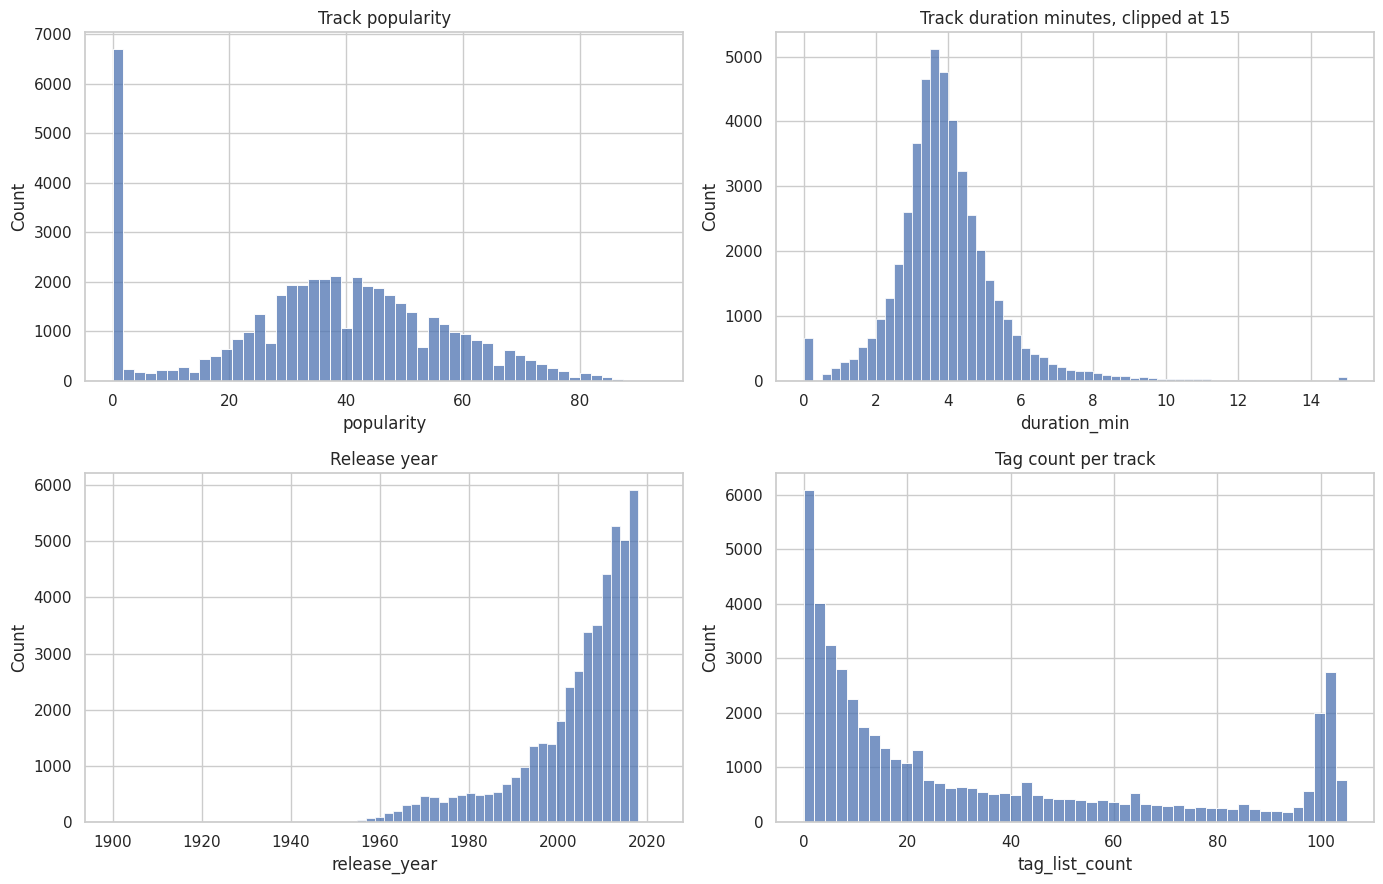

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(track_df["popularity"].dropna(), bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Track popularity")

sns.histplot(track_df["duration_min"].dropna().clip(upper=15), bins=60, ax=axes[0, 1])
axes[0, 1].set_title("Track duration minutes, clipped at 15")

sns.histplot(track_df["release_year"].dropna(), bins=60, ax=axes[1, 0])
axes[1, 0].set_title("Release year")

sns.histplot(track_df["tag_list_count"], bins=50, ax=axes[1, 1])
axes[1, 1].set_title("Tag count per track")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "track_metadata_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

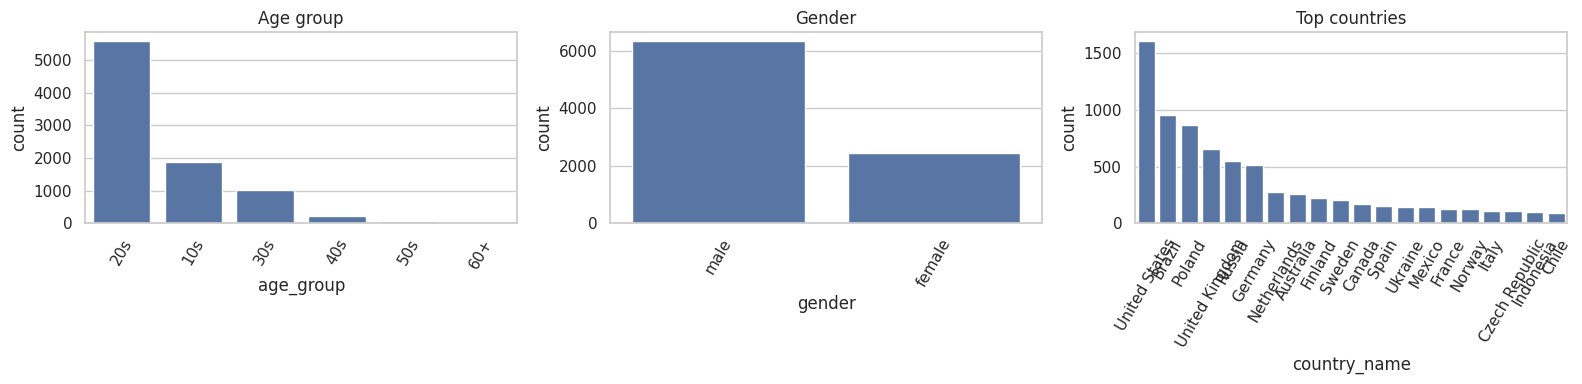

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in zip(axes, ["age_group", "gender", "country_name"], ["Age group", "Gender", "Top countries"]):
    order = user_df[col].value_counts().head(20).index
    sns.countplot(data=user_df[user_df[col].isin(order)], x=col, order=order, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "user_profile_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

user_profile_stats = []
for col in ["age_group", "gender", "country_code", "country_name"]:
    vc = user_df[col].value_counts(dropna=False).reset_index()
    vc.columns = ["value", "count"]
    vc.insert(0, "field", col)
    user_profile_stats.append(vc)
user_profile_stats = pd.concat(user_profile_stats, ignore_index=True)
user_profile_stats.to_csv(TABLE_DIR / "user_profile_stats.csv", index=False)

## ID coverage / leakage checks

提出制約に関わる ID coverage を確認します。推薦候補は `all_tracks` が前提で、`test_tracks` のみへ閉じる実験は避けます。

In [11]:
def parquet_id_set(paths, id_col: str) -> set[str]:
    ids = set()
    for path in paths:
        table = pq.read_table(path, columns=[id_col])
        ids.update(table[id_col].to_pylist())
    return ids

track_embedding_all_ids = parquet_id_set(track_embedding_paths_all, "track_id")
track_embedding_test_ids = parquet_id_set(track_embedding_paths_test, "track_id")
user_metadata_ids = set(user_df["user_id"])
user_embedding_ids_by_split = {
    infer_split_name(path): parquet_id_set([path], "user_id")
    for path in user_embedding_paths
}
user_embedding_all_ids = set().union(*user_embedding_ids_by_split.values())

music_ids_by_split = {split: set(music_df.loc[music_df["split"] == split, "track_id"]) for split in music_df["split"].unique()}
session_ids_by_split = {split: set(sessions_df.loc[sessions_df["split"] == split, "session_id"]) for split in sessions_df["split"].unique()}
user_ids_by_split = {split: set(sessions_df.loc[sessions_df["split"] == split, "user_id"]) for split in sessions_df["split"].unique()}

coverage_rows = []
for split, ids in music_ids_by_split.items():
    coverage_rows.append({
        "check": f"conversation_music_track_ids_in_all_tracks:{split}",
        "left_count": len(ids),
        "right_count": len(track_all_ids),
        "intersection": len(ids & track_all_ids),
        "missing": len(ids - track_all_ids),
        "coverage_rate": len(ids & track_all_ids) / len(ids) if ids else 1.0,
    })
for split, ids in music_ids_by_split.items():
    coverage_rows.append({
        "check": f"conversation_music_track_ids_in_test_tracks:{split}",
        "left_count": len(ids),
        "right_count": len(track_test_ids),
        "intersection": len(ids & track_test_ids),
        "missing": len(ids - track_test_ids),
        "coverage_rate": len(ids & track_test_ids) / len(ids) if ids else 1.0,
    })
coverage_rows.extend([
    {"check": "test_tracks_subset_of_all_tracks", "left_count": len(track_test_ids), "right_count": len(track_all_ids), "intersection": len(track_test_ids & track_all_ids), "missing": len(track_test_ids - track_all_ids), "coverage_rate": len(track_test_ids & track_all_ids) / len(track_test_ids)},
    {"check": "track_embedding_all_ids_in_all_tracks", "left_count": len(track_embedding_all_ids), "right_count": len(track_all_ids), "intersection": len(track_embedding_all_ids & track_all_ids), "missing": len(track_embedding_all_ids - track_all_ids), "coverage_rate": len(track_embedding_all_ids & track_all_ids) / len(track_embedding_all_ids)},
    {"check": "track_metadata_all_tracks_in_track_embeddings", "left_count": len(track_all_ids), "right_count": len(track_embedding_all_ids), "intersection": len(track_all_ids & track_embedding_all_ids), "missing": len(track_all_ids - track_embedding_all_ids), "coverage_rate": len(track_all_ids & track_embedding_all_ids) / len(track_all_ids)},
])
for split, ids in user_ids_by_split.items():
    coverage_rows.append({
        "check": f"conversation_user_ids_in_user_metadata:{split}",
        "left_count": len(ids),
        "right_count": len(user_metadata_ids),
        "intersection": len(ids & user_metadata_ids),
        "missing": len(ids - user_metadata_ids),
        "coverage_rate": len(ids & user_metadata_ids) / len(ids) if ids else 1.0,
    })
    coverage_rows.append({
        "check": f"conversation_user_ids_in_user_embeddings:{split}",
        "left_count": len(ids),
        "right_count": len(user_embedding_all_ids),
        "intersection": len(ids & user_embedding_all_ids),
        "missing": len(ids - user_embedding_all_ids),
        "coverage_rate": len(ids & user_embedding_all_ids) / len(ids) if ids else 1.0,
    })

for a, b in [("train", "dev_test"), ("train", "blind_a"), ("dev_test", "blind_a")]:
    coverage_rows.append({
        "check": f"session_overlap:{a}:{b}",
        "left_count": len(session_ids_by_split[a]),
        "right_count": len(session_ids_by_split[b]),
        "intersection": len(session_ids_by_split[a] & session_ids_by_split[b]),
        "missing": None,
        "coverage_rate": None,
    })
    coverage_rows.append({
        "check": f"user_overlap:{a}:{b}",
        "left_count": len(user_ids_by_split[a]),
        "right_count": len(user_ids_by_split[b]),
        "intersection": len(user_ids_by_split[a] & user_ids_by_split[b]),
        "missing": None,
        "coverage_rate": None,
    })

id_coverage = pd.DataFrame(coverage_rows)
id_coverage.to_csv(TABLE_DIR / "id_coverage.csv", index=False)
display(id_coverage)

music_all_cov = id_coverage[id_coverage["check"].str.startswith("conversation_music_track_ids_in_all_tracks")]
assert (music_all_cov["missing"] == 0).all(), music_all_cov

,check,left_count,right_count,intersection,missing,coverage_rate
0,conversation_music_track_ids_in_all_tracks:train,43597,47071,43597,0.0,1.000000
1,conversation_music_track_ids_in_all_tracks:dev_test,6761,47071,6761,0.0,1.000000
2,conversation_music_track_ids_in_all_tracks:blind_a,208,47071,208,0.0,1.000000
3,conversation_music_track_ids_in_test_tracks:train,43597,7405,3931,39666.0,0.090167
4,conversation_music_track_ids_in_test_tracks:dev_test,6761,7405,6761,0.0,1.000000
5,conversation_music_track_ids_in_test_tracks:blind_a,208,7405,208,0.0,1.000000
6,test_tracks_subset_of_all_tracks,7405,47071,7405,0.0,1.000000
7,track_embedding_all_ids_in_all_tracks,47071,47071,47071,0.0,1.000000
8,track_metadata_all_tracks_in_track_embeddings,47071,47071,47071,0.0,1.000000
9,conversation_user_ids_in_user_metadata:train,8591,8772,8591,0.0,1.000000


## Embedding EDA

各 embedding 列の次元、null、ゼロベクトル、norm 分布を確認します。Track embeddings は `all_tracks` の各 modality を列ごとに batch scan します。

In [12]:
def vector_stats_for_paths(paths, id_col: str, vector_cols: list[str], sample_norms_per_col: int | None = None, batch_size: int = 512):
    summary_rows = []
    norm_rows = []
    for col in vector_cols:
        rows = 0
        nulls = 0
        zeros = 0
        dims = Counter()
        norms = []
        for path in paths:
            pf = pq.ParquetFile(path)
            for batch in pf.iter_batches(columns=[id_col, col], batch_size=batch_size):
                ids = batch.column(id_col).to_pylist()
                vectors = batch.column(col)
                for row_id, scalar in zip(ids, vectors):
                    rows += 1
                    vector = scalar.as_py()
                    if vector is None:
                        nulls += 1
                        continue
                    dims[len(vector)] += 1
                    arr = np.asarray(vector, dtype=np.float32)
                    norm = float(np.linalg.norm(arr))
                    if norm == 0.0:
                        zeros += 1
                    if sample_norms_per_col is None or len(norms) < sample_norms_per_col:
                        norms.append(norm)
        non_null = rows - nulls
        summary_rows.append({
            "column": col,
            "rows": rows,
            "non_null": non_null,
            "nulls": nulls,
            "zero_vectors": zeros,
            "dim_distribution": dict(dims),
            "primary_dim": next((dim for dim, _ in dims.most_common() if dim > 0), dims.most_common(1)[0][0] if dims else None),
            "norm_mean": float(np.mean(norms)) if norms else np.nan,
            "norm_std": float(np.std(norms)) if norms else np.nan,
            "norm_min": float(np.min(norms)) if norms else np.nan,
            "norm_median": float(np.median(norms)) if norms else np.nan,
            "norm_max": float(np.max(norms)) if norms else np.nan,
            "norm_sample_size": len(norms),
        })
        for norm in norms:
            norm_rows.append({"column": col, "norm": norm})
    return pd.DataFrame(summary_rows), pd.DataFrame(norm_rows)

track_embedding_cols = [
    "audio-laion_clap",
    "image-siglip2",
    "cf-bpr",
    "attributes-qwen3_embedding_0.6b",
    "lyrics-qwen3_embedding_0.6b",
    "metadata-qwen3_embedding_0.6b",
]
track_embedding_stats, track_embedding_norms = vector_stats_for_paths(track_embedding_paths_all, "track_id", track_embedding_cols, sample_norms_per_col=None)
track_embedding_stats.to_csv(TABLE_DIR / "track_embedding_stats.csv", index=False)
track_embedding_norms.to_csv(TABLE_DIR / "track_embedding_norms.csv", index=False)
display(track_embedding_stats)

,column,rows,non_null,nulls,zero_vectors,dim_distribution,primary_dim,norm_mean,norm_std,norm_min,norm_median,norm_max,norm_sample_size
0,audio-laion_clap,47071,47071,0,492,"{512: 46579, 0: 492}",512,0.989548,0.101701,0.0,1.000000,1.000000,47071
1,image-siglip2,47071,47071,0,586,"{768: 46485, 0: 586}",768,10.017822,1.423597,0.0,10.065743,14.411309,47071
2,cf-bpr,47071,47071,0,616,"{128: 46455, 0: 616}",128,0.027243,0.004177,0.0,0.027601,0.042065,47071
3,attributes-qwen3_embedding_0.6b,47071,47071,0,492,"{1024: 46579, 0: 492}",1024,89.518976,9.907738,0.0,90.546692,113.675400,47071
4,lyrics-qwen3_embedding_0.6b,47071,47071,0,492,"{1024: 46579, 0: 492}",1024,106.509881,13.091959,0.0,108.320297,123.201599,47071
5,metadata-qwen3_embedding_0.6b,47071,47071,0,492,"{1024: 46579, 0: 492}",1024,97.184384,11.616590,0.0,97.755882,119.970451,47071


In [13]:
user_embedding_stats_frames = []
user_embedding_norm_frames = []
for path in user_embedding_paths:
    split = infer_split_name(path)
    stats, norms = vector_stats_for_paths([path], "user_id", ["cf-bpr"], sample_norms_per_col=None)
    stats.insert(0, "split", split)
    norms.insert(0, "split", split)
    user_embedding_stats_frames.append(stats)
    user_embedding_norm_frames.append(norms)
user_embedding_stats = pd.concat(user_embedding_stats_frames, ignore_index=True)
user_embedding_norms = pd.concat(user_embedding_norm_frames, ignore_index=True)
user_embedding_stats.to_csv(TABLE_DIR / "user_embedding_stats.csv", index=False)
user_embedding_norms.to_csv(TABLE_DIR / "user_embedding_norms.csv", index=False)
display(user_embedding_stats)

,split,column,rows,non_null,nulls,zero_vectors,dim_distribution,primary_dim,norm_mean,norm_std,norm_min,norm_median,norm_max,norm_sample_size
0,test_cold,cf-bpr,129,129,0,104,"{0: 104, 128: 25}",128,0.009372,0.022228,0.000000,0.000000,0.131841,129
1,test_warm,cf-bpr,371,371,0,0,{128: 371},128,0.067687,0.024528,0.026113,0.065051,0.208073,371
2,train,cf-bpr,8591,8591,0,0,{128: 8591},128,0.039888,0.011730,0.020437,0.037508,0.208073,8591


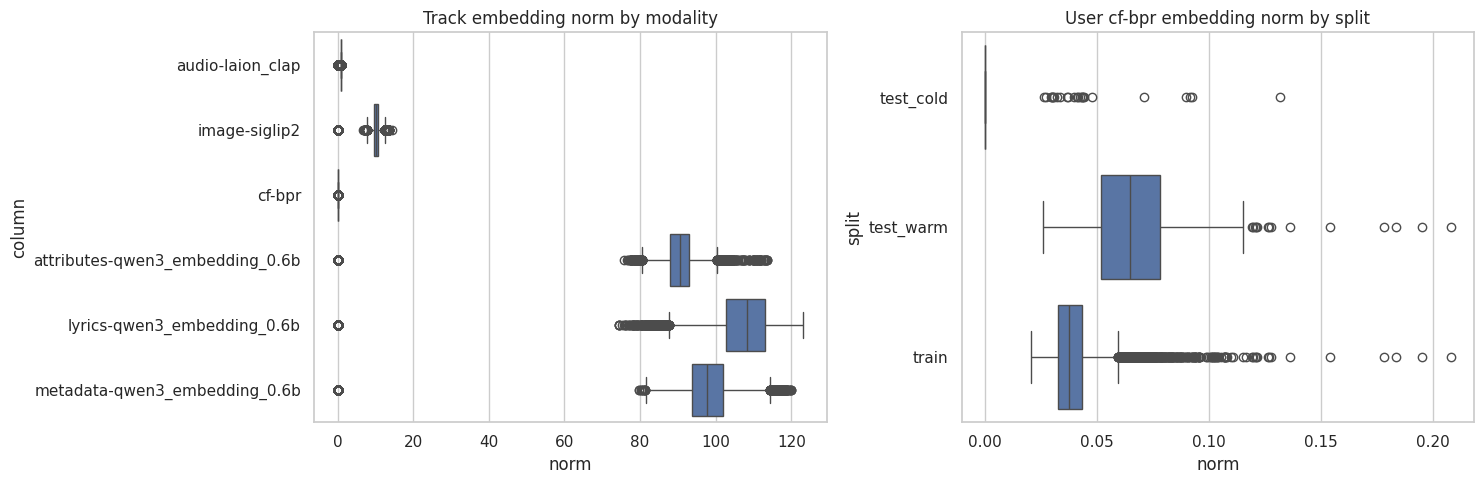

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=track_embedding_norms, y="column", x="norm", ax=axes[0])
axes[0].set_title("Track embedding norm by modality")

sns.boxplot(data=user_embedding_norms, y="split", x="norm", ax=axes[1])
axes[1].set_title("User cf-bpr embedding norm by split")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "embedding_norms.png", dpi=160, bbox_inches="tight")
plt.show()

## Baseline improvement notes

EDA から retrieval / reranking の次実験に繋がる観察を整理します。candidate recall@20/50/100 はこの Notebook の後続実験として、BM25/BERT retrieval の出力と dev 正解 track を突き合わせます。

In [15]:
train_music_refs = music_df[music_df["split"] == "train"]
dev_music_refs = music_df[music_df["split"] == "dev_test"]
blind_music_refs = music_df[music_df["split"] == "blind_a"]

summary_lines = []
summary_lines.append("# input データ EDA サマリー")
summary_lines.append("")
summary_lines.append("## 行数検証")
for _, row in row_counts.iterrows():
    summary_lines.append(f"- {row['name']}: {int(row['rows']):,} 行、期待値 {int(row['expected']):,}、一致={bool(row['matches_expected'])}")
summary_lines.append("")
summary_lines.append("## 会話データの構造")
for _, row in conversation_stats.iterrows():
    summary_lines.append(
        f"- {row['split']}: {int(row['sessions']):,} sessions、{int(row['users']):,} users、"
        f"session あたり平均 rows={row['avg_rows']:.2f}、平均 music 件数={row['avg_music_messages']:.2f}。"
    )
summary_lines.append("")
summary_lines.append("## ID coverage")
for _, row in id_coverage[id_coverage["check"].str.contains("music_track_ids_in_all_tracks")].iterrows():
    summary_lines.append(f"- {row['check']}: missing={int(row['missing'])}、coverage={row['coverage_rate']:.4f}")
summary_lines.append(f"- test_tracks は all_tracks に包含: missing={int(id_coverage.loc[id_coverage['check']=='test_tracks_subset_of_all_tracks', 'missing'].iloc[0])}")
summary_lines.append("")
summary_lines.append("## Metadata の観察")
unique_artist_values = len(set(v for values in track_df["artist_name"] for v in iter_list_values(values)))
summary_lines.append(f"- all_tracks は {len(track_df):,} tracks、ユニーク artist 名 {unique_artist_values:,}、tag 数の中央値 {track_df['tag_list_count'].median():.1f}。")
summary_lines.append(f"- popularity 中央値={track_df['popularity'].median():.2f}、duration 中央値={track_df['duration_min'].median():.2f} 分。")
summary_lines.append("")
summary_lines.append("## Embedding の観察")
for _, row in track_embedding_stats.iterrows():
    summary_lines.append(f"- track {row['column']}: dim={row['primary_dim']}、nulls={int(row['nulls'])}、zero_vectors={int(row['zero_vectors'])}、norm_median={row['norm_median']:.4f}")
for _, row in user_embedding_stats.iterrows():
    summary_lines.append(f"- user {row['split']} {row['column']}: dim={row['primary_dim']}、rows={int(row['rows'])}、nulls={int(row['nulls'])}、norm_median={row['norm_median']:.4f}")
summary_lines.append("")
summary_lines.append("## 次の実験候補")
summary_lines.append("- BM25 corpus を比較する: title/artist/album baseline に対して tag_list と release_date を追加する。")
summary_lines.append("- dev で diagnostic candidate recall@20/50/100 を測る。retrieval candidate と target turn の music-role track id を突き合わせる。")
summary_lines.append("- turn number 別・goal category 別の人気 prior を reranker feature として試す。最終推薦対象は all_tracks を維持する。")
summary_lines.append("- 広めの BM25/BERT candidate generation の後段で、metadata-qwen3 と cf-bpr embeddings による reranking を試す。")
summary_lines.append("")
summary_lines.append("## 生成物")
summary_lines.append("- tables: data_inventory.csv、conversation_stats.csv、id_coverage.csv、top_tracks_artists_tags.csv、および補助集計テーブル。")
summary_lines.append("- figures: conversation_distributions.png、track_metadata_distributions.png、user_profile_distributions.png、embedding_norms.png。")

SUMMARY_PATH.write_text("\n".join(summary_lines) + "\n", encoding="utf-8")
print(SUMMARY_PATH.read_text(encoding="utf-8"))

# input データ EDA サマリー

## 行数検証
- conversation_train: 15,199 行、期待値 15,199、一致=True
- conversation_dev_test: 1,000 行、期待値 1,000、一致=True
- conversation_blind_a: 80 行、期待値 80、一致=True
- track_metadata_all_tracks: 47,071 行、期待値 47,071、一致=True
- track_metadata_test_tracks: 7,405 行、期待値 7,405、一致=True
- user_metadata_all_users: 8,772 行、期待値 8,772、一致=True

## 会話データの構造
- blind_a: 80 sessions、58 users、session あたり平均 rows=8.88、平均 music 件数=2.62。
- dev_test: 1,000 sessions、500 users、session あたり平均 rows=24.00、平均 music 件数=8.00。
- train: 15,199 sessions、8,591 users、session あたり平均 rows=24.00、平均 music 件数=8.00。

## ID coverage
- conversation_music_track_ids_in_all_tracks:train: missing=0、coverage=1.0000
- conversation_music_track_ids_in_all_tracks:dev_test: missing=0、coverage=1.0000
- conversation_music_track_ids_in_all_tracks:blind_a: missing=0、coverage=1.0000
- test_tracks は all_tracks に包含: missing=0

## Metadata の観察
- all_tracks は 47,071 tracks、ユニーク artist 名 10,637、tag 数の中央値 17.0。
- popularity 中央値=38.00、duration 